In [2]:
### 检查cuda信息
! nvidia-smi

Sun Apr  5 14:26:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P0             27W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install --upgrade gdown

# Main link
!gdown --id '1o6Ag-G3qItSmYhTheX6DYiuyNzWyHyTc' --output libriphone.zip

# Backup link 1
# !gdown --id '1R1uQYi4QpX0tBfUWt2mbZcncdBsJkxeW' --output libriphone.zip

# Bqckup link 2
# !wget -O libriphone.zip "https://www.dropbox.com/s/wqww8c5dbrl2ka9/libriphone.zip?dl=1"

!unzip -q libriphone.zip
!ls libriphone

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1o6Ag-G3qItSmYhTheX6DYiuyNzWyHyTc
From (redirected): https://drive.google.com/uc?id=1o6Ag-G3qItSmYhTheX6DYiuyNzWyHyTc&confirm=t&uuid=6d7d2985-27bd-476b-88a1-bed2aaf3e55d
To: /content/libriphone.zip
100% 479M/479M [00:02<00:00, 166MB/s]  
replace libriphone/.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

feat  test_split.txt  train_labels.txt	train_split.txt


In [1]:
# loading packages
## 
import os
import random
import pandas as pd
import torch
from tqdm import tqdm

def load_feat(path):
    return torch.load(path)

def shift(x, n):

    if n < 0:
        left = x[0].repeat(-n, 1)
        right = x[:n]
    elif n > 0:
        right = x[-1].repeat(n,1)
        left = x[n:]
    
    return torch.cat((left,right), dim = 0)

def concat_feat(x, concat_n):

    assert concat_n % 2 == 1

    if concat_n < 2:
        return x

    seq_len, feature_dim = x.size(0), x.size(1)

    x = x.repeat(1, concat_n)

    x = x.view(seq_len, concat_n, feature_dim).permute(1,0,2)

    mid = (concat_n // 2)
    for i in range(1, mid + 1):
        x[mid + i, :] = shift(x[mid + i], i)
        x[mid - i, :] = shift(x[mid - i], -i)
    
    return x.permute(1,0,2).view(seq_len, concat_n * feature_dim)
    
def preprocess_data(split, feat_dir, phone_path, concat_nframes, train_ratio = 0.8, train_val_seed = 1337):
    class_num = 41
    mode = 'train' if (split == 'train' or split == 'val') else 'test'

    label_dict = {}
    if mode != 'test': # 不是test也就是train，把label拿到
        phone_file = os.path.join(phone_path, f"{mode}_labels.txt")
        phone_file = open(phone_file, mode='r').readlines()

        for i in phone_file:
            i = i.strip('\n').split(' ')
            label_dict[i[0]] = [int(p) for p in i[1:]]
        
    if split == 'train' or split == 'val':
        usage_list = open(os.path.join(phone_path, 'train_split.txt')).readlines()
        random.seed(train_val_seed)
        random.shuffle(usage_list)
        percentage = int(len(usage_list) * train_ratio)
        usage_list = usage_list[:percentage] if split == 'train' else \
        usage_list[percentage:]
    elif split == 'test':
        usage_list = open(os.path.join(phone_path, 'test_split.txt')).readlines()
    else:
        raise ValueError('Invalid \'split\' argument for dataset: PhoneDataset!')
    
    usage_list = [i.strip('\n') for i in usage_list]

    print(f"[Dataset] - # phone classes: {str(class_num)} number of utterances for {split}: {str(len(usage_list))}")

    max_len = 3000000
    X = torch.empty(size=[max_len, 39 * concat_nframes])
    if mode != 'test':
        y = torch.empty(size = [max_len], dtype=torch.long)
    
    idx = 0
    for _, fname in tqdm(enumerate(usage_list)):
        feat = load_feat(os.path.join(feat_dir, mode, f"{fname}.pt")) ### da
        cur_len = len(feat)
        feat = concat_feat(feat, concat_nframes)
        if mode != 'test':
            label = torch.LongTensor(label_dict[fname])

        X[idx: idx + cur_len, :] = feat

        
        if mode != 'test':
            y[idx: idx + cur_len ] = label
        
        idx = idx + cur_len
    X = X[:idx, :]
    if mode != 'test':
        y = y[:idx]
    print(f'[INFO] {split} set')
    print(X.shape)
    if mode != 'test':
        print(y.shape)
        return X,y
    else:
        return X

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
class LibriDataset(Dataset):
    def __init__(self, X, y = None):
        self.data = X
        if y is not None:
            self.label = torch.LongTensor(y)
        else:
            self.label = None
        
    def __getitem__(self, idx):
        return self.data[idx] if self.label is None else (self.data[idx], self.label[idx])

    def __len__(self):
        return len(self.data) 

In [2]:
import torch.nn as nn
import torch.nn.functional as F 
class BasicBlock(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()

        self.block = nn.Sequential(
            nn.Linear(input_dim,output_dim),
            nn.BatchNorm1d(output_dim),
            nn.LeakyReLU(),
            nn.Dropout(0.2)
        )

    def forward(self,x):
        return self.block(x)

class Classifier(nn.Module):
    def __init__(self, input_dim, output_dim = 41, hidden_layers = 6, hidden_dim = 512):
        super().__init__()
        self.fc = nn.Sequential(
            BasicBlock(input_dim, hidden_dim),
            *[BasicBlock(hidden_dim,hidden_dim) for _ in range(hidden_layers)],
            nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, x):
        return self.fc(x)

In [3]:
concat_nframes = 31
train_ratio = 0.8
seed = 0
num_epochs = 1
batch_size = 1024
learning_rate = 0.0001
model_path = './model.ckpt'
input_dim = concat_nframes * 39
hidden_layers = 1
hidden_dim = 512


In [ ]:
import gc
train_X, train_y = preprocess_data('train', './libriphone/feat','./libriphone', concat_nframes, train_ratio=train_ratio)
val_X, val_y = preprocess_data('val', './libriphone/feat','./libriphone', concat_nframes, train_ratio=train_ratio)
train_set = LibriDataset(train_X, train_y)
val_set = LibriDataset(val_X, val_y)

del train_X, train_y, val_X, val_y
gc.collect()

train_loader = DataLoader(train_set,batch_size = batch_size, shuffle=True)
val_loader = DataLoader(val_set,batch_size=batch_size, shuffle = False)

[Dataset] - # phone classes: 41 number of utterances for train: 3428


3428it [00:35, 95.60it/s] 


[INFO] train set
torch.Size([2116368, 1209])
torch.Size([2116368])
[Dataset] - # phone classes: 41 number of utterances for val: 858


515it [00:23, 47.37it/s] 

: 

: 

: 

In [ ]:
print(train_set.size())

In [46]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

Device: cuda


In [47]:
import numpy as np
np.random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

model = Classifier(input_dim).to(device)
optimizer = torch.optim.AdamW(model.parameters(),lr=learning_rate)
criterion = nn.CrossEntropyLoss()

In [ ]:
best_acc = 0
train_accs, train_losses, val_accs, val_losses = [], [], [], []
count = 0
early_count = 10
for epoch in range(num_epochs):
    model.train()
    train_loss, train_acc = 0.0, 0.0   # 初始化
    for _, batch in enumerate(tqdm(train_loader)):
        optimizer.zero_grad()
        features, labels = batch
        features, labels = features.to(device), labels.to(device)
        pred = model(features)# parameter 的require_grad属性是True 因此 顺序计算pred张量的require = True 建立计算图 
        loss = criterion(pred, labels) #继续建立计算图
        loss.backward()
        optimizer.step()
        _,train_pred = torch.max(pred, 1) # 建立计算图 
        train_loss += loss.detach().cpu().item() ### loss数据部分和原来一样 但是require部分是false 之后计算train_loss 也没有计算图 防止显存爆炸
        # train_acc = np.mean((train_pred == labels).detach().cpu())
        train_acc += (train_pred.detach() == labels).float().mean().item()  
    train_loss /= len(train_loader)
    train_acc /= len(train_loader)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    if len(val_loader.dataset) > 0:
        model.eval()
        val_loss, val_acc = 0.0, 0.0   # 初始化
        for _, batch in enumerate(tqdm(val_loader)):
            features, labels = batch
            features, labels = features.to(device), labels.to(device)
            with torch.no_grad():
                pred = model(features)
                loss = criterion(pred, labels)
                _, val_pred = torch.max(pred, 1)
            # val_loss = loss.detach().cpu().item()
            val_loss += loss.cpu().item() ### 不建立计算图 前馈网络
            val_acc += (val_pred == labels).float().mean().item()
        val_loss /= len(val_loader)
        val_acc /= len(val_loader)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

    print('[{:03d}/{:03d}] Train Acc: {:3.6f} Loss: {:3.6f} | Val Acc: {:3.6f} loss: {:3.6f}'.format(
                epoch + 1, num_epochs, train_acc, train_loss, val_acc, val_loss
            ))
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), f = model_path)
        print(f"Saving model with best acc {best_acc}...")
        count = 0
    else:
        count += 1
        if count >= early_count:
            print(f"Early stopping at epoch {epoch + 1}")
            break

100%|██████████| 516/516 [00:02<00:00, 252.12it/s]


[001/100] Train Acc: 0.511934 Loss: 1.662558 | Val Acc: 0.616120 loss: 1.247887
Saving model with best acc 0.6161201297081718...


100%|██████████| 516/516 [00:02<00:00, 237.13it/s]


[002/100] Train Acc: 0.597510 Loss: 1.316547 | Val Acc: 0.652456 loss: 1.118015
Saving model with best acc 0.6524563618870669...


100%|██████████| 516/516 [00:01<00:00, 312.73it/s]


...

[098/100] Train Acc: 0.761579 Loss: 0.737450 | Val Acc: 0.760234 loss: 0.758831


100%|██████████| 516/516 [00:01<00:00, 271.16it/s]


[099/100] Train Acc: 0.761854 Loss: 0.736550 | Val Acc: 0.760459 loss: 0.758959
Saving model with best acc 0.7604590336712755...


100%|██████████| 516/516 [00:01<00:00, 312.83it/s]

[100/100] Train Acc: 0.762260 Loss: 0.735746 | Val Acc: 0.760028 loss: 0.758766


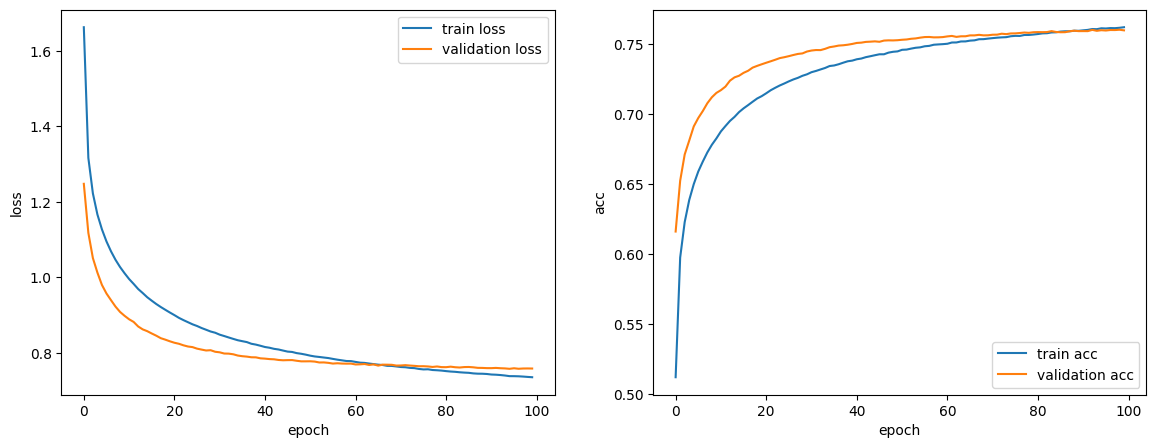

In [49]:
### 画图
import matplotlib.pyplot as plt
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label = 'train loss')
plt.plot(val_losses, label = 'validation loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.subplot(1,2,2)
plt.plot(train_accs,label = 'train acc')
plt.plot(val_accs, label = 'validation acc')
plt.xlabel('epoch')
plt.ylabel('acc')
plt.legend()


In [50]:
# del train_loader, val_loader
test_X = preprocess_data(split= 'test', feat_dir= './libriphone/feat', phone_path= './libriphone', concat_nframes=concat_nframes)
test_set = LibriDataset(test_X, y = None)
test_loader = DataLoader(test_set,batch_size,shuffle=False)

[Dataset] - # phone classes: 41 number of utterances for test: 1078


1078it [00:01, 956.20it/s]

[INFO] test set
torch.Size([646268, 1209])


In [51]:
del model
model = Classifier(input_dim=input_dim).to(device)
model.load_state_dict(torch.load(model_path))


<All keys matched successfully>

In [52]:
preds = []
model.eval()
for x in tqdm(test_loader):
    x = x.to(device)
    with torch.no_grad():
        pred = model(x)
        _, test_pred = torch.max(pred, 1) ### 
    preds.append(test_pred.cpu().numpy())
result = np.concatenate(preds, axis=0)
with open('prediction.csv', 'w') as f:
    f.write('Id,Class\n')
    for i, y in enumerate(result):
        f.write('{},{}\n'.format(i, y))  

100%|██████████| 632/632 [00:01<00:00, 514.81it/s]


In [53]:
print(result)

[0 0 0 ... 0 0 0]


In [ ]:
test_acc = 0
test_lengths = 0
pred = np.array([], dtype=np.int32)

model.eval()
with torch.no_grad():
    for i, batch in enumerate(tqdm(test_loader)):
        features = batch
        features = features.to(device)

        outputs = model(features)

        _, test_pred = torch.max(outputs, 1) # get the index of the class with the highest probability
        pred = np.concatenate((pred, test_pred.cpu().numpy()), axis=0)

100%|██████████| 632/632 [00:01<00:00, 543.48it/s]


In [55]:
print(len(pred))

646268


In [56]:
with open('prediction.csv', 'w') as f:
    f.write('Id,Class\n')
    for i, y in enumerate(pred):
        f.write('{},{}\n'.format(i, y))

In [8]:
import torch
w = torch.tensor([1.,2,3],requires_grad=True)
w.data
w.grad = torch.tensor([1.0,1,1])

In [10]:
print(w.data.detach())
print(w.grad.detach())

tensor([1., 2., 3.])
tensor([1., 1., 1.])


In [11]:
print(w.detach().data)

tensor([1., 2., 3.])


In [ ]:
import torch
import numpy as np
a = torch.randn(size = [28,28])
print(a)
print(a.cpu().numpy().shape)
b = np.concatenate(a.cpu().numpy(),dim = 1)
print(b)

tensor([[ 0.5057,  1.4434,  0.8262,  0.2044,  0.9500, -0.0136, -0.3694,  0.2632,
         -0.2040, -1.2158, -0.0074, -1.2255,  0.6283,  1.2035,  0.0410,  0.6248,
          0.3772, -1.0549,  0.6222,  0.4256, -2.1255,  0.6050,  0.2329, -0.3762,
         -0.4095, -0.2032,  1.7016,  1.3599],
        [ 0.7790,  1.7665,  0.8967,  0.7609,  1.4546,  0.4849, -0.3257,  1.1292,
          0.1684,  1.5525, -1.7654,  1.8789,  0.4837,  1.3167,  0.3899,  0.4023,
         -0.0850,  0.3206,  0.0620, -1.6323, -1.0043,  0.6326,  0.1458, -1.5108,
         -0.7363,  0.9153, -0.3131,  0.0854],
        [ 0.4553, -0.2372,  0.9429, -1.2251,  1.2441,  0.4163, -2.1875, -0.7665,
         -0.8396, -1.3024, -0.3714,  0.0195,  0.5192, -0.4059, -0.0972, -0.9835,
         -1.5333,  0.2162,  1.1160,  0.0533, -0.2860, -0.9997, -0.9291,  0.0745,
          1.0008,  1.9369, -0.6174,  0.5381],
        [ 0.1036, -0.7088,  1.3420,  0.4735, -1.6874, -1.5165,  1.8467, -0.8106,
         -0.4281,  0.1104, -1.0741,  1.4333, -1.0361

In [ ]:
### test
import torch
# a = torch.tensor([[1],[2],[3]], dtype=torch.float32)
my_list = []
for i in range(10):
    my_list.append(torch.tensor([[i],[i+1],[i+2]]))
final_list = torch.cat(my_list, dim = 0)
print(final_list)

tensor([[ 0],
        [ 1],
        [ 2],
        [ 1],
        [ 2],
        [ 3],
        [ 2],
        [ 3],
        [ 4],
        [ 3],
        [ 4],
        [ 5],
        [ 4],
        [ 5],
        [ 6],
        [ 5],
        [ 6],
        [ 7],
        [ 6],
        [ 7],
        [ 8],
        [ 7],
        [ 8],
        [ 9],
        [ 8],
        [ 9],
        [10],
        [ 9],
        [10],
        [11]])


In [ ]:
### test
import torch
import numpy as np
# a = torch.tensor([[1],[2],[3]], dtype=torch.float32)
my_list = []
for i in range(10):
    my_list.append(torch.tensor([[i],[i+1],[i+2]]).numpy().astype(float))
final_list = np.concatenate(my_list,axis=0)
print(final_list)

[[ 0.]
 [ 1.]
 [ 2.]
 [ 1.]
 [ 2.]
 [ 3.]
 [ 2.]
 [ 3.]
 [ 4.]
 [ 3.]
 [ 4.]
 [ 5.]
 [ 4.]
 [ 5.]
 [ 6.]
 [ 5.]
 [ 6.]
 [ 7.]
 [ 6.]
 [ 7.]
 [ 8.]
 [ 7.]
 [ 8.]
 [ 9.]
 [ 8.]
 [ 9.]
 [10.]
 [ 9.]
 [10.]
 [11.]]


In [ ]:
import torch
a = torch.randn(size=[3,10,5])
print(a)



tensor([[[-0.2544, -0.4197,  0.7726,  0.9572, -0.4175],
         [ 1.4356, -0.1090,  0.9461,  0.4150,  0.1244],
         [-1.6449,  1.7210, -0.9391, -0.2082,  1.7038],
         [ 1.0420, -0.1735, -2.7972,  0.9033,  0.4017],
         [ 0.7796,  0.6633,  1.0896,  0.0263, -0.5550],
         [ 0.5814, -0.4259,  0.7551, -0.2436, -2.0497],
         [ 1.0813,  1.0717,  0.1585, -0.4986, -1.8110],
         [ 1.1659, -0.8029, -0.6387,  0.3536,  0.0118],
         [ 0.1276, -0.6446, -1.2685,  0.4801, -0.8483],
         [-0.1578, -0.6798, -2.5891, -1.7066,  0.4174]],

        [[-1.1823, -2.6092,  1.0778, -0.6499, -0.4545],
         [ 0.4314, -0.5569, -0.2027, -0.7252, -1.7519],
         [-1.1076, -0.7395,  0.6118, -1.1862, -0.8203],
         [-2.2717, -0.9100, -1.2364, -2.7222,  1.2262],
         [-0.1021,  0.5411,  1.3534,  0.5320, -0.8068],
         [ 0.7154,  0.3609,  0.0378,  1.2393, -1.5535],
         [-0.9743,  0.3277,  0.6187,  0.7076, -1.2447],
         [-1.3451,  0.9752, -0.8996,  0.8227, 

In [36]:
print(a.flatten(1,-1).shape)
print(a.flatten(1,-1))
_, pred = torch.max(a.flatten(1,-1),dim= 1)
print(pred.size())

torch.Size([3, 50])
tensor([[-0.2544, -0.4197,  0.7726,  0.9572, -0.4175,  1.4356, -0.1090,  0.9461,
          0.4150,  0.1244, -1.6449,  1.7210, -0.9391, -0.2082,  1.7038,  1.0420,
         -0.1735, -2.7972,  0.9033,  0.4017,  0.7796,  0.6633,  1.0896,  0.0263,
         -0.5550,  0.5814, -0.4259,  0.7551, -0.2436, -2.0497,  1.0813,  1.0717,
          0.1585, -0.4986, -1.8110,  1.1659, -0.8029, -0.6387,  0.3536,  0.0118,
          0.1276, -0.6446, -1.2685,  0.4801, -0.8483, -0.1578, -0.6798, -2.5891,
         -1.7066,  0.4174],
        [-1.1823, -2.6092,  1.0778, -0.6499, -0.4545,  0.4314, -0.5569, -0.2027,
         -0.7252, -1.7519, -1.1076, -0.7395,  0.6118, -1.1862, -0.8203, -2.2717,
         -0.9100, -1.2364, -2.7222,  1.2262, -0.1021,  0.5411,  1.3534,  0.5320,
         -0.8068,  0.7154,  0.3609,  0.0378,  1.2393, -1.5535, -0.9743,  0.3277,
          0.6187,  0.7076, -1.2447, -1.3451,  0.9752, -0.8996,  0.8227, -0.7510,
          1.2731,  0.3822,  0.7746, -0.5547,  0.5917,  0.2890

In [ ]:
 from torchvision.utils.

In [13]:
### CNN实验
### 设置参数
import torch 
in_channels = 5
out_channels = 10
height = 100
width = 100
kernel_size = 3
batch_size = 100
input_x = torch.randn(size=[batch_size, in_channels, height, width])
convo_layer = torch.nn.Conv2d(in_channels,out_channels, kernel_size)
out_put = convo_layer(input_x)
print(input_x.size())
print(convo_layer.weight.shape)
print(out_put.size())

torch.Size([100, 5, 100, 100])
torch.Size([10, 5, 3, 3])
torch.Size([100, 10, 98, 98])


In [28]:
import torch
import numpy as np
input = np.arange(36)
input = torch.tensor(input).view(1,1,6,6).float()
conv = torch.nn.Conv2d(in_channels=1, out_channels= 1,kernel_size=3, padding=1,bias=False,stride=1)
conv.weight.data = torch.randn(size=conv.weight.shape)
print(conv.weight)
output = conv(input)
print(output.shape)  ### 如何计算的公式需要掌握 (输入的大小 - kernel size大小) / stride + 1; padding  = 1 相当于加两层 

Parameter containing:
tensor([[[[-0.1952, -0.7966,  2.2321],
          [-0.8472, -0.6234, -0.2944],
          [ 2.8692,  0.6553,  1.3927]]]], requires_grad=True)
torch.Size([1, 1, 6, 6])


In [29]:
maxpooling = torch.nn.MaxPool2d(2)
output2 = maxpooling(output)
print(output2.shape)

torch.Size([1, 1, 3, 3])
